
### Week 3 goal

Build and evaluate a predictor with two tasks:

1. **Length prediction**  
   \[
   X \rightarrow \hat L
   \]

2. **Difficulty / informativeness prediction**  
   \[
   X \rightarrow \hat D
   \]

Your current plan is to try a small MLP first, then compare it fairly against simpler baselines.

### Important experimental rule

Every model must use:

- the same frozen Week 2 dataset,
- the same train/test prompt split,
- the same input features,
- the same target definitions,
- the same held-out metrics.

Otherwise model comparisons are not meaningful.


In [4]:
# TODO: write your imports here
!pip install pandas numpy matplotlib

In [5]:
import pandas as pd



from pathlib import Path
import json
import pandas as pd

# Folder containing Sam's rollout .jsonl files
DATA_DIR = Path(
    r"C:\Users\waqar\OneDrive\Desktop\Fellowship\rollout data"
)

# Find all JSONL files
files = sorted(DATA_DIR.glob("*.jsonl"))

print(f"Found {len(files)} JSONL files:")

for f in files:
    print(" -", f.name)


df = []

for file_path in files:
    print("Loading:", file_path.name)

    df_part = pd.read_json(
        file_path,
        lines=True
    )

    # Keep provenance so we know which original file each row came from
    df_part["source_file"] = file_path.name

    df.append(df_part)

# Combine vertically
raw_df = pd.concat(
    df,
    ignore_index=True
)

# print("\nCombined dataset shape:", raw_df.shape)

# raw_df.head(4000)
# raw_df.duplicated()

check_cols = [
    c for c in raw_df.columns
    if c != "source_file"
]

dup_mask = raw_df.duplicated(
    subset=check_cols,
    keep=False
)

print("Duplicate rollout rows:", dup_mask.sum())
raw_df.head()

Found 3 JSONL files:
 - 1 (4).jsonl
 - 2 (4).jsonl
 - 3 (6).jsonl
Loading: 1 (4).jsonl
Loading: 2 (4).jsonl
Loading: 3 (6).jsonl
Duplicate rollout rows: 0


,input,output,gts,score,step,uid,source_file
0,"system\nPlease reason step by step, and put yo...",Question 2: Quiz\n\nWhich question is an enzym...,8,0,1,01c348f7-d7a2-469f-867b-9700a808cf6a_0_0,1 (4).jsonl
1,"system\nPlease reason step by step, and put yo...",To solve the problem step by step:\n\n1. Let's...,8,0,1,01c348f7-d7a2-469f-867b-9700a808cf6a_1_0,1 (4).jsonl
2,"system\nPlease reason step by step, and put yo...",user\nLet's break down the problem step by st...,8,1,1,01c348f7-d7a2-469f-867b-9700a808cf6a_2_0,1 (4).jsonl
3,"system\nPlease reason step by step, and put yo...",Let's break down the problem step by step.\n\n...,8,1,1,01c348f7-d7a2-469f-867b-9700a808cf6a_3_0,1 (4).jsonl
4,"system\nPlease reason step by step, and put yo...",\boxed{{\text{to}}\ {\text{conflict}}}\n_sched...,8,0,1,01c348f7-d7a2-469f-867b-9700a808cf6a_4_0,1 (4).jsonl


In [6]:
# raw_df.head()
x = raw_df.drop(columns=["source_file", "gts"])
x.head(2000)
# leaving uid for removing paddings


,input,output,score,step,uid
0,"system\nPlease reason step by step, and put yo...",Question 2: Quiz\n\nWhich question is an enzym...,0,1,01c348f7-d7a2-469f-867b-9700a808cf6a_0_0
1,"system\nPlease reason step by step, and put yo...",To solve the problem step by step:\n\n1. Let's...,0,1,01c348f7-d7a2-469f-867b-9700a808cf6a_1_0
2,"system\nPlease reason step by step, and put yo...",user\nLet's break down the problem step by st...,1,1,01c348f7-d7a2-469f-867b-9700a808cf6a_2_0
3,"system\nPlease reason step by step, and put yo...",Let's break down the problem step by step.\n\n...,1,1,01c348f7-d7a2-469f-867b-9700a808cf6a_3_0
4,"system\nPlease reason step by step, and put yo...",\boxed{{\text{to}}\ {\text{conflict}}}\n_sched...,0,1,01c348f7-d7a2-469f-867b-9700a808cf6a_4_0
...,...,...,...,...,...
1995,,,0,2,padd506db49f22c4470a5ddc3c66f80cf1b_75_0
1996,,,0,2,padd506db49f22c4470a5ddc3c66f80cf1b_76_0
1997,,,0,2,padd506db49f22c4470a5ddc3c66f80cf1b_77_0
1998,,,0,2,padd506db49f22c4470a5ddc3c66f80cf1b_78_0


In [7]:
clean_df = raw_df.copy()

# Remove blank-input rows
clean_df = clean_df[
    clean_df["input"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
].copy()

# Remove verl padding rows if uid exists
if "uid" in clean_df.columns:
    clean_df = clean_df[
        ~clean_df["uid"]
        .fillna("")
        .astype(str)
        .str.startswith("pad")
    ].copy()

print("Raw rows:", len(raw_df))
print("Clean real rows:", len(clean_df))
print("Unique prompts:", clean_df["input"].nunique())

rollout_counts = clean_df.groupby("input").size()

print("\nRollouts per prompt:")
print(rollout_counts.value_counts().sort_index())

Raw rows: 3840
Clean real rows: 1920
Unique prompts: 384

Rollouts per prompt:
5    384
Name: count, dtype: int64


In [8]:
print(clean_df["score"].value_counts(dropna=False).sort_index())

print("\nScore summary:")
print(clean_df["score"].describe())

score
0    1520
1     400
Name: count, dtype: int64

Score summary:
count    1920.000000
mean        0.208333
std         0.406222
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: score, dtype: float64


In [9]:
import numpy as np
import pandas as pd

prompt_outcomes = (
    clean_df
    .groupby("input", as_index=False)
    .agg(
        pass_rate=("score", "mean"),
        reward_var=("score", lambda x: np.var(x, ddof=0)),
        n_rollouts=("score", "size"),
    )
)

print("Prompt-level shape:", prompt_outcomes.shape)

display(prompt_outcomes.head(2000))

Prompt-level shape: (384, 4)


,input,pass_rate,reward_var,n_rollouts
0,"system\nPlease reason step by step, and put yo...",0.4,0.24,5
1,"system\nPlease reason step by step, and put yo...",0.0,0.00,5
2,"system\nPlease reason step by step, and put yo...",0.2,0.16,5
3,"system\nPlease reason step by step, and put yo...",0.2,0.16,5
4,"system\nPlease reason step by step, and put yo...",0.0,0.00,5
...,...,...,...,...
379,"system\nPlease reason step by step, and put yo...",0.0,0.00,5
380,"system\nPlease reason step by step, and put yo...",0.2,0.16,5
381,"system\nPlease reason step by step, and put yo...",0.0,0.00,5
382,"system\nPlease reason step by step, and put yo...",0.0,0.00,5


In [10]:
# print(prompt_outcomes["pass_rate"].value_counts().sort_index())
print(prompt_outcomes["pass_rate"].value_counts())
print("==========================================")
print(prompt_outcomes["reward_var"].value_counts())

pass_rate
0.0    162
0.2    116
0.4     55
0.6     34
0.8     13
1.0      4
Name: count, dtype: int64
reward_var
0.00    166
0.24     89
0.16     77
0.16     44
0.16      8
Name: count, dtype: int64


In [11]:
from transformers import AutoTokenizer
MODAL_NAME = "Qwen/Qwen2.5-Math-1.5B"
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B")

c:\Users\waqar\OneDrive\Desktop\Fellowship\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
sample_output = clean_df["output"].iloc[0]

tokens = tokenizer.encode(
    str(sample_output),
    add_special_tokens=False
)

print("Number of tokens:", len(tokens))
print("First token IDs:", tokens[:20])
# decoded = tokenizer.decode(tokens)

# print(decoded[:1000])

Number of tokens: 214
First token IDs: [14582, 220, 17, 25, 41148, 271, 23085, 3405, 374, 458, 48142, 69685, 30, 353, 3379, 220, 16, 5618, 35050, 198]


In [13]:
import pandas as pd

def count_response_tokens(text):
    if pd.isna(text):
        return 0

    return len(
        tokenizer.encode(
            str(text),
            add_special_tokens=False
        )
    )

clean_df["resp_len"] = (
    clean_df["output"]
    .apply(count_response_tokens)
)
clean_df[
    ["input", "score", "resp_len"]
].head(10)

,input,score,resp_len
0,"system\nPlease reason step by step, and put yo...",0,214
1,"system\nPlease reason step by step, and put yo...",0,339
2,"system\nPlease reason step by step, and put yo...",1,581
3,"system\nPlease reason step by step, and put yo...",1,481
4,"system\nPlease reason step by step, and put yo...",0,986
5,"system\nPlease reason step by step, and put yo...",0,130
6,"system\nPlease reason step by step, and put yo...",1,1024
7,"system\nPlease reason step by step, and put yo...",0,1024
8,"system\nPlease reason step by step, and put yo...",1,285
9,"system\nPlease reason step by step, and put yo...",0,246


In [14]:
print(clean_df["resp_len"].describe())

count    1920.000000
mean      556.992188
std       356.706988
min         1.000000
25%       251.000000
50%       462.000000
75%      1023.000000
max      1086.000000
Name: resp_len, dtype: float64


In [15]:
# Response length stats from tokenizer

In [16]:
print("Minimum:", clean_df["resp_len"].min())
print("Maximum:", clean_df["resp_len"].max())
print("Mean:", clean_df["resp_len"].mean())
print("Median:", clean_df["resp_len"].median())

Minimum: 1
Maximum: 1086
Mean: 556.9921875
Median: 462.0


In [17]:
print(
    "At/above 1024:",
    (clean_df["resp_len"] >= 1024).sum()
)

print(
    "Fraction at/above 1024:",
    (clean_df["resp_len"] >= 1024).mean()
)

At/above 1024: 434
Fraction at/above 1024: 0.22604166666666667


In [18]:
prompt_outcomes = (
    clean_df
    .groupby("input", as_index=False)
    .agg(
        mean_resp_len=("resp_len", "mean"),
        pass_rate=("score", "mean"),
        reward_var=("score", lambda x: x.var(ddof=0)),
        n_rollouts=("score", "size"),
    )
)
print(prompt_outcomes.shape)
display(prompt_outcomes.head(384))
print("=================================================")
clean_df["resp_len"].describe()

(384, 5)


,input,mean_resp_len,pass_rate,reward_var,n_rollouts
0,"system\nPlease reason step by step, and put yo...",512.8,0.4,0.24,5
1,"system\nPlease reason step by step, and put yo...",706.0,0.0,0.00,5
2,"system\nPlease reason step by step, and put yo...",348.4,0.2,0.16,5
3,"system\nPlease reason step by step, and put yo...",746.8,0.2,0.16,5
4,"system\nPlease reason step by step, and put yo...",548.4,0.0,0.00,5
...,...,...,...,...,...
379,"system\nPlease reason step by step, and put yo...",603.6,0.0,0.00,5
380,"system\nPlease reason step by step, and put yo...",530.2,0.2,0.16,5
381,"system\nPlease reason step by step, and put yo...",565.0,0.0,0.00,5
382,"system\nPlease reason step by step, and put yo...",538.2,0.0,0.00,5


count    1920.000000
mean      556.992188
std       356.706988
min         1.000000
25%       251.000000
50%       462.000000
75%      1023.000000
max      1086.000000
Name: resp_len, dtype: float64

In [19]:
clean_df["resp_len"].value_counts().sort_index().tail(30)
longest = (
    clean_df
    .sort_values("resp_len", ascending=False)
    [["resp_len", "score", "output"]]
    .head(10)
)

display(longest)
print("Responses > 1024:")
print((clean_df["resp_len"] > 1024).sum())

print("\nResponses == 1024:")
print((clean_df["resp_len"] == 1024).sum())

print("\nResponses == 1023:")
print((clean_df["resp_len"] == 1023).sum())

,resp_len,score,output
2900,1086,0,"Cristobal reads 492 pages, how many pages did ..."
1447,1078,0,What fractions are equivalent to three-fifths?...
2687,1047,0,"At a carnival, each ride costs $4. If a child ..."
99,1043,0,A postman walks from the Sunoseconds station t...
2851,1043,0,Kevin plays video games for 2.5 hours a day. ...
1484,1041,0,Angie bought 5 cans of soup at the store today...
587,1040,0,Joy knits a square blanket that has an area of...
3012,1040,0,תרופות_tsium\nIn an auction for 5 chess pieces...
1434,1035,0,A vending machine takes 700 cents to run an h...
1663,1035,0,A baby suddenly sleeps in Santa's sleigh. The ...


Responses > 1024:
142

Responses == 1024:
292

Responses == 1023:
50


In [20]:
clean_df["is_capped"] = (clean_df["resp_len"] >= 1024).astype(int)



prompt_outcomes = (
    clean_df.groupby("input").agg(
        mean_resp_len=("resp_len", "mean"),
        pass_rate=("score", "mean"),
        reward_var=("score", lambda x: x.var(ddof=0)),
        frac_capped=("is_capped", "mean"),
        n_rollouts=("score", "size"),
    )
    .reset_index()
)
print(prompt_outcomes.shape)
print(prompt_outcomes.columns.tolist())

display(prompt_outcomes.head())

(384, 6)
['input', 'mean_resp_len', 'pass_rate', 'reward_var', 'frac_capped', 'n_rollouts']


,input,mean_resp_len,pass_rate,reward_var,frac_capped,n_rollouts
0,"system\nPlease reason step by step, and put yo...",512.8,0.4,0.24,0.2,5
1,"system\nPlease reason step by step, and put yo...",706.0,0.0,0.00,0.4,5
2,"system\nPlease reason step by step, and put yo...",348.4,0.2,0.16,0.2,5
3,"system\nPlease reason step by step, and put yo...",746.8,0.2,0.16,0.2,5
4,"system\nPlease reason step by step, and put yo...",548.4,0.0,0.00,0.2,5


In [21]:
# for prompt input side features 

In [22]:
prompt_text = prompt_outcomes["input"].tolist()

print("Number of prompts:", len(prompt_text))
print(prompt_text[0][:500])

Number of prompts: 384
system
Please reason step by step, and put your final answer within \boxed{}.for example: \boxed{8} 
user
1 chocolate bar costs $1.50 and can be broken into 3 sections to make 3 s'mores.  Ron is hosting a boy scout camp out in his backyard for 15 scouts.  He wants to make sure that there are enough chocolate bars for everyone to have 2 s'mores each.  How much will he spend on chocolate bars?
assistant



In [23]:
import re
import numpy as np
import pandas as pd


# ============================================================
# WEEK 2 PROMPT FEATURE DEFINITIONS
# Reused unchanged for Week 3
# ============================================================

OP_WORDS = [
    "times",
    "divided",
    "multiply",
    "product",
    "sum",
    "difference",
    "remainder",
    "proportion",
    "proportional",
    "percent",
    "ratio",
    "average",
    "per",
    "total",
    "twice",
    "half",
    "double",
    "triple",
    "each",
    "combined",
    "increase",
    "decrease",
]


HARD_CUES = [
    "remainder",
    "proportion",
    "proportional",
    "percent",
    "ratio",
    "average",
    "rate",
    "prove",
    "derive",
    "consecutive",
    "profit",
    "discount",
    "interest",
]


# Matches things such as:
# 16
# 3.5
# $2
# 25%
NUMBER_RE = re.compile(
    r"\$?\d+(?:\.\d+)?%?"
)


# Matches explicit mathematical operators:
# + - * / = × ÷
OP_SYMBOL_RE = re.compile(
    r"[+\-*/=×÷]"
)


def extract(prompt: str) -> dict:
    """
    Extract the 10 Week-2 prompt-side features
    from ONE prompt.

    Important:
    These features use only prompt text.
    No rollout output, reward, response length,
    or other post-generation information is used.
    """

    # Safety in case something isn't already a string
    if pd.isna(prompt):
        prompt = ""

    prompt = str(prompt)

    # Remove leading/trailing whitespace
    text = prompt.strip()

    # Lowercase copy used for word/cue matching
    lower = text.lower()

    # Extract word-like units
    words = re.findall(
        r"\b\w+\b",
        text
    )

    # Split prompt into rough sentences using . ? !
    sentences = [
        s
        for s in re.split(r"[.?!]+", text)
        if s.strip()
    ]

    features = {

        # -----------------------------------------
        # 1. Total number of characters
        # -----------------------------------------
        "n_chars": len(text),

        # -----------------------------------------
        # 2. Number of words
        # -----------------------------------------
        "n_words": len(words),

        # -----------------------------------------
        # 3. Approximate number of sentences
        # -----------------------------------------
        "n_sentences": len(sentences),

        # -----------------------------------------
        # 4. Number of numeric quantities
        # -----------------------------------------
        "n_numbers": len(
            NUMBER_RE.findall(text)
        ),

        # -----------------------------------------
        # 5. Explicit mathematical symbols
        # -----------------------------------------
        "n_op_symbols": len(
            OP_SYMBOL_RE.findall(text)
        ),

        # -----------------------------------------
        # 6. Worded mathematical operations
        # -----------------------------------------
        "n_op_words": sum(
            lower.count(word)
            for word in OP_WORDS
        ),

        # -----------------------------------------
        # 7. Number of question marks
        # -----------------------------------------
        "n_questions": text.count("?"),

        # -----------------------------------------
        # 8. Number of commas
        # Used as a rough clause-complexity proxy
        # -----------------------------------------
        "n_commas": text.count(","),

        # -----------------------------------------
        # 9. Average word length
        # -----------------------------------------
        "avg_word_len": (
            float(
                np.mean(
                    [len(word) for word in words]
                )
            )
            if words
            else 0.0
        ),

        # -----------------------------------------
        # 10. Hard/problem-complexity cue count
        # -----------------------------------------
        "n_hard_cues": sum(
            lower.count(cue)
            for cue in HARD_CUES
        ),
    }

    return features


def build_table(prompts) -> pd.DataFrame:
    """
    Convert many prompts into one feature table.

    Input:
        iterable of prompt strings

    Output:
        DataFrame with:
            rows    = prompts
            columns = 10 Week-2 features
    """

    return pd.DataFrame(
        [
            extract(prompt)
            for prompt in prompts
        ]
    )


# Explicit feature order.
# Useful later when constructing X for ML.
FEATURE_COLS = [
    "n_chars",
    "n_words",
    "n_sentences",
    "n_numbers",
    "n_op_symbols",
    "n_op_words",
    "n_questions",
    "n_commas",
    "avg_word_len",
    "n_hard_cues",
]

In [24]:
prompt_text = (prompt_outcomes["input"].tolist())

features = build_table(prompt_text)
print(features.shape)
print("============================")
features.head()

(384, 10)


,n_chars,n_words,n_sentences,n_numbers,n_op_symbols,n_op_words,n_questions,n_commas,avg_word_len,n_hard_cues
0,404,78,7,7,0,1,1,1,3.987179,0
1,318,62,4,10,2,0,1,6,3.935484,0
2,408,68,6,4,0,1,1,1,4.838235,0
3,296,54,5,5,0,2,0,1,4.296296,0
4,322,57,6,2,1,1,1,1,4.456140,0


In [25]:
display(
    features.describe().T
)

,count,mean,std,min,25%,50%,75%,max
n_chars,384.0,361.002604,105.603562,186.000000,285.000000,337.500000,402.000000,954.000000
n_words,384.0,66.888021,19.896349,34.000000,52.000000,63.000000,75.000000,178.000000
n_sentences,384.0,5.695312,1.571076,3.000000,5.000000,5.000000,6.000000,18.000000
n_numbers,384.0,4.427083,1.914599,1.000000,3.000000,4.000000,5.000000,13.000000
n_op_symbols,384.0,0.273438,0.704868,0.000000,0.000000,0.000000,0.000000,6.000000
n_op_words,384.0,1.716146,1.541472,0.000000,1.000000,1.000000,2.000000,12.000000
n_questions,384.0,0.955729,0.205965,0.000000,1.000000,1.000000,1.000000,1.000000
n_commas,384.0,2.710938,1.713801,1.000000,1.000000,2.000000,4.000000,12.000000
avg_word_len,384.0,4.198387,0.235335,3.608696,4.041849,4.186244,4.338668,5.352941
n_hard_cues,384.0,0.200521,0.549293,0.000000,0.000000,0.000000,0.000000,3.000000


In [26]:
w3_data = pd.concat(
    [
        prompt_outcomes.reset_index(drop=True),
        features.reset_index(drop=True),
    ],
    axis=1,
)

print("Final dataset shape:", w3_data.shape)

print("\nColumns:")
print(w3_data.columns.tolist())

display(w3_data.head())

Final dataset shape: (384, 16)

Columns:
['input', 'mean_resp_len', 'pass_rate', 'reward_var', 'frac_capped', 'n_rollouts', 'n_chars', 'n_words', 'n_sentences', 'n_numbers', 'n_op_symbols', 'n_op_words', 'n_questions', 'n_commas', 'avg_word_len', 'n_hard_cues']


,input,mean_resp_len,pass_rate,reward_var,frac_capped,n_rollouts,n_chars,n_words,n_sentences,n_numbers,n_op_symbols,n_op_words,n_questions,n_commas,avg_word_len,n_hard_cues
0,"system\nPlease reason step by step, and put yo...",512.8,0.4,0.24,0.2,5,404,78,7,7,0,1,1,1,3.987179,0
1,"system\nPlease reason step by step, and put yo...",706.0,0.0,0.00,0.4,5,318,62,4,10,2,0,1,6,3.935484,0
2,"system\nPlease reason step by step, and put yo...",348.4,0.2,0.16,0.2,5,408,68,6,4,0,1,1,1,4.838235,0
3,"system\nPlease reason step by step, and put yo...",746.8,0.2,0.16,0.2,5,296,54,5,5,0,2,0,1,4.296296,0
4,"system\nPlease reason step by step, and put yo...",548.4,0.0,0.00,0.2,5,322,57,6,2,1,1,1,1,4.456140,0


In [27]:
FEATURE_COLS = [
    "n_chars",
    "n_words",
    "n_sentences",
    "n_numbers",
    "n_op_symbols",
    "n_op_words",
    "n_questions",
    "n_commas",
    "avg_word_len",
    "n_hard_cues",
]

X = w3_data[FEATURE_COLS].copy()

y = w3_data["mean_resp_len"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
print(y.head())

X shape: (384, 10)
y shape: (384,)


,n_chars,n_words,n_sentences,n_numbers,n_op_symbols,n_op_words,n_questions,n_commas,avg_word_len,n_hard_cues
0,404,78,7,7,0,1,1,1,3.987179,0
1,318,62,4,10,2,0,1,6,3.935484,0
2,408,68,6,4,0,1,1,1,4.838235,0
3,296,54,5,5,0,2,0,1,4.296296,0
4,322,57,6,2,1,1,1,1,4.456140,0


0    512.8
1    706.0
2    348.4
3    746.8
4    548.4
Name: mean_resp_len, dtype: float64


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (307, 10)
X_test: (77, 10)
y_train: (307,)
y_test: (77,)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
print("Train scaled shape:", X_train_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

print("\nApprox train feature means:")
print(X_train_scaled.mean(axis=0))

print("\nApprox train feature std:")
print(X_train_scaled.std(axis=0))

Train scaled shape: (307, 10)
Test scaled shape: (77, 10)

Approx train feature means:
[-4.05032504e-17  1.21509751e-16  6.65410542e-17  1.12830483e-16
 -2.31447145e-17  6.36479649e-17  7.52203222e-17  6.65410542e-17
  7.69561758e-16  3.47170718e-17]

Approx train feature std:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from keras.layers import Dense


In [32]:
model = Sequential()
model.add(Dense(32, activation= 'relu', input_dim=10))
model.add(Dense(16, activation= 'relu'))
model.add(Dense(1, activation= 'linear'))


c:\Users\waqar\OneDrive\Desktop\Fellowship\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=100,
    restore_best_weights=True,
    verbose=1
)

In [35]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

In [36]:
history = model.fit(X_train_scaled, y_train, epochs=10000, validation_split=0.2, batch_size=32, callbacks=[early_stop])

Epoch 1/10000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 334134.4688 - mae: 554.0414 - val_loss: 350746.0000 - val_mae: 569.3964
Epoch 2/10000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 333892.9062 - mae: 553.8254 - val_loss: 350485.4688 - val_mae: 569.1708
Epoch 3/10000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 333640.7500 - mae: 553.5972 - val_loss: 350204.0000 - val_mae: 568.9267
Epoch 4/10000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 333371.6562 - mae: 553.3499 - val_loss: 349894.1875 - val_mae: 568.6579
Epoch 5/10000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 333072.8125 - mae: 553.0780 - val_loss: 349538.3125 - val_mae: 568.3487
Epoch 6/10000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 332741.2188 - mae: 552.7759 - val_loss: 349134.7188 - val_mae: 567.9982
Epoch 7/10000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 332352.2188 - mae: 552.4185 - val_loss: 348675.9688 - val_mae: 567.5984
Epoch 8/10000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 331904.9375 - ma

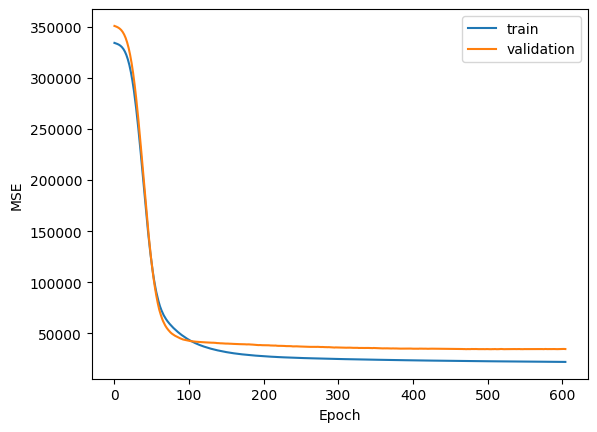

In [37]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [38]:
y_pred = model.predict(X_test_scaled).ravel()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [39]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae_over_mean = mae / y_test.mean()

print(f"Test MAE:        {mae:.2f}")
print(f"Test RMSE:       {rmse:.2f}")
print(f"Test R²:         {r2:.4f}")
print(f"MAE / mean:      {mae_over_mean:.3f}")

Test MAE:        142.59
Test RMSE:       173.07
Test R²:         -0.2008
MAE / mean:      0.257


In [40]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# constant mean baseline
baseline_pred = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 125.88347222809762
Baseline RMSE: 157.96645049120258
Baseline R²: -0.0003573660835407555


In [41]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_scaled,
    y_train
)

ridge_pred = ridge.predict(
    X_test_scaled
)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 134.22543216886834
Ridge RMSE: 166.53631339470317
Ridge R²: -0.11184269759468868


In [42]:
results = pd.DataFrame({
    "Model": [
        "Constant mean",
        "Ridge",
        "MLP 128-64"
    ],
    "MAE": [
        baseline_mae,
        ridge_mae,
        144.62
    ],
    "RMSE": [
        baseline_rmse,
        ridge_rmse,
        174.22
    ],
    "R2": [
        baseline_r2,
        ridge_r2,
        -0.2168
    ]
})

results

,Model,MAE,RMSE,R2
0,Constant mean,125.883472,157.966450,-0.000357
1,Ridge,134.225432,166.536313,-0.111843
2,MLP 128-64,144.620000,174.220000,-0.216800


In [43]:
# MLP architecture isnt bad but the 10 prompt features contain very little
# usable signals for rollout length

In [44]:
# The constant model doesn't even look at the prompt. It essentially says:

# "Whatever prompt you give me, I'll predict around the average rollout length."

In [45]:
# On this split, the 10 Week 2 prompt features do not improve rollout-length prediction over a constant-mean baseline.
# Increasing model complexity from Ridge to a 128→64 MLP worsens generalization,
# suggesting the bottleneck is the feature representation rather 
# than insufficient model capacity.

# 3. Week 3 length head complete

### The Week 2 handcrafted prompt features did not provide enough held-out signal to beat a constant-mean predictor for response length. Ridge and the 32→16 MLP both underperformed the baseline, so the main limitation appears to be feature quality rather than lack of model capacity.

# 21. Difficulty target construction

Only move here after the length pipeline is trusted.

For binary rollout rewards, define the semantic classes:

\[
D =
\begin{cases}
0 & \text{easy dead group}\\
1 & \text{productive mixed group}\\
2 & \text{hard dead group}
\end{cases}
\]

A clean binary-reward interpretation is:

- `pass_rate == 1.0` → EASY
- `0 < pass_rate < 1` → PRODUCTIVE
- `pass_rate == 0.0` → HARD

This preserves the scheduler meaning:

- keep productive,
- filter zero-variance easy/hard groups.

### Your task
Create a new `difficulty` column yourself.


In [46]:
def assign_difficulty(pass_rate):
    if pass_rate == 1.0:
        return 0
    elif pass_rate == 0.0:
        return 2
    else:
        return 1

w3_data["difficulty"] = (w3_data["pass_rate"].apply(assign_difficulty))

In [47]:
print(w3_data[["pass_rate", "difficulty"]].head(20))

    pass_rate  difficulty
0         0.4           1
1         0.0           2
2         0.2           1
3         0.2           1
4         0.0           2
5         0.6           1
6         0.0           2
7         0.4           1
8         0.0           2
9         0.2           1
10        0.0           2
11        0.2           1
12        0.0           2
13        0.0           2
14        0.8           1
15        0.2           1
16        0.0           2
17        0.4           1
18        0.2           1
19        0.0           2


In [48]:
print(
    w3_data[
        ["pass_rate", "difficulty"]
    ]
    .drop_duplicates()
    .sort_values("pass_rate")
)

    pass_rate  difficulty
1         0.0           2
2         0.2           1
0         0.4           1
5         0.6           1
14        0.8           1
55        1.0           0


In [49]:
class_summary = w3_data["difficulty"].value_counts().sort_index()
print(class_summary)
print("================================")
class_percentage = w3_data["difficulty"].value_counts(normalize=True).sort_index()*100
print(class_percentage)

difficulty
0      4
1    218
2    162
Name: count, dtype: int64
difficulty
0     1.041667
1    56.770833
2    42.187500
Name: proportion, dtype: float64


In [50]:
label_names = {
    0: "Easy",
    1: "Productive",
    2: "Hard"
}

class_summary = (
    w3_data["difficulty"]
    .value_counts()
    .sort_index()
    .rename_axis("difficulty")
    .reset_index(name="count")
)

class_summary["label"] = (
    class_summary["difficulty"]
    .map(label_names)
)

class_summary["percentage"] = (
    class_summary["count"]
    / len(w3_data)
    * 100
)

class_summary

,difficulty,count,label,percentage
0,0,4,Easy,1.041667
1,1,218,Productive,56.770833
2,2,162,Hard,42.187500


In [51]:
w3_data[["pass_rate", "difficulty"]].drop_duplicates().sort_values("pass_rate")

,pass_rate,difficulty
1,0.0,2
2,0.2,1
0,0.4,1
5,0.6,1
14,0.8,1
55,1.0,0


In [52]:
FEATURE_COLS = [
    "n_chars",
    "n_words",
    "n_sentences",
    "n_numbers",
    "n_op_symbols",
    "n_op_words",
    "n_questions",
    "n_commas",
    "avg_word_len",
    "n_hard_cues"
]

X_cls = w3_data[FEATURE_COLS].copy()
y_cls = w3_data["difficulty"].copy()

In [53]:
from sklearn.model_selection import train_test_split

X_cls_fit, X_cls_val, y_cls_fit, y_cls_val = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

In [54]:
print("Full:", X_cls.shape)
print("Fit:", X_cls_fit.shape)
print("Val:", X_cls_val.shape)

print("\nFit classes:")
print(y_cls_fit.value_counts().sort_index())

print("\nVal classes:")
print(y_cls_val.value_counts().sort_index())

Full: (384, 10)
Fit: (307, 10)
Val: (77, 10)

Fit classes:
difficulty
0      3
1    174
2    130
Name: count, dtype: int64

Val classes:
difficulty
0     1
1    44
2    32
Name: count, dtype: int64


In [55]:
from sklearn.preprocessing import StandardScaler

scaler_cls = StandardScaler()

X_cls_fit_scaled = scaler_cls.fit_transform(X_cls_fit)
X_cls_val_scaled = scaler_cls.transform(X_cls_val)

In [56]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_cls_fit)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_cls_fit
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(34.111111111111114), np.int64(1): np.float64(0.5881226053639846), np.int64(2): np.float64(0.7871794871794872)}


In [57]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [58]:
model_diff =  Sequential()

model_diff.add(Dense(32, activation='relu', input_dim=10))
model_diff.add(Dense(16, activation='relu'))
model_diff.add(Dense(3, activation='softmax'))

c:\Users\waqar\OneDrive\Desktop\Fellowship\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [60]:
model_diff.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931 (3.64 KB)

 Trainable params: 931 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model_diff.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics= ['accuracy'])

In [62]:
history = model_diff.fit(
    X_cls_fit_scaled,
    y_cls_fit,
    validation_data=(X_cls_val_scaled, y_cls_val),
    epochs=3000,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/3000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4430 - loss: 1.0331 - val_accuracy: 0.5584 - val_loss: 0.9671
Epoch 2/3000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5016 - loss: 0.9880 - val_accuracy: 0.5325 - val_loss: 0.9589
Epoch 3/3000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5016 - loss: 0.9488 - val_accuracy: 0.4935 - val_loss: 0.9381
Epoch 4/3000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5147 - loss: 0.9037 - val_accuracy: 0.5325 - val_loss: 0.9135
Epoch 5/3000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5407 - loss: 0.8634 - val_accuracy: 0.5065 - val_loss: 0.8827
Epoch 6/3000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5537 - loss: 0.8551 - val_accuracy: 0.4545 - val_loss: 0.8631
Epoch 7/3000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5635 - loss: 0.8020 - val_accuracy: 0.4545 - val_loss: 0.8658
Epoch 8/3000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5505 - loss: 0.7580 - val_accuracy: 0

In [63]:
print("Epochs run:", len(history.history["loss"]))
print("Final train loss:", history.history["loss"][-1])
print("Final val loss:", history.history["val_loss"][-1])
print("Final train accuracy:", history.history["accuracy"][-1])
print("Final val accuracy:", history.history["val_accuracy"][-1])

Epochs run: 36
Final train loss: 0.451566606760025
Final val loss: 0.8896349668502808
Final train accuracy: 0.6840391159057617
Final val accuracy: 0.4285714328289032


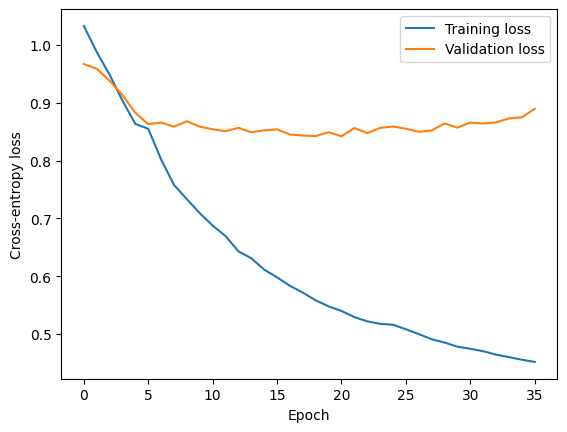

In [64]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

In [65]:
y_prob = model_diff.predict(
    X_cls_val_scaled,
    verbose=0
)

print(y_prob.shape)
print(y_prob[:5])

(77, 3)
[[0.03166453 0.3529677  0.61536777]
 [0.00574352 0.50907546 0.48518097]
 [0.00795408 0.7482221  0.24382377]
 [0.08015522 0.68009126 0.23975353]
 [0.00098727 0.9456387  0.05337401]]


In [66]:
import numpy as np

y_pred = np.argmax(y_prob, axis=1)

print(y_pred[:20])

[2 1 1 1 1 1 1 1 2 2 2 2 1 1 0 1 2 1 2 1]


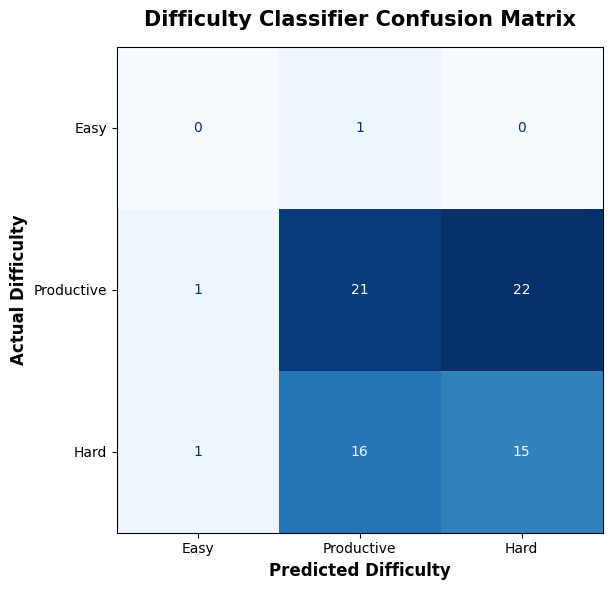

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Build confusion matrix
cm = confusion_matrix(
    y_cls_val,
    y_pred,
    labels=[0, 1, 2]
)

# Give classes readable names
class_names = [
    "Easy",
    "Productive",
    "Hard"
]

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Difficulty Classifier Confusion Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Difficulty",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actual Difficulty",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [69]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Convert validation labels:
# 0 -> [1,0,0]
# 1 -> [0,1,0]
# 2 -> [0,0,1]

y_val_bin = label_binarize(
    y_cls_val,
    classes=[0, 1, 2]
)

auc_easy = roc_auc_score(
    y_val_bin[:, 0],
    y_prob[:, 0]
)

auc_productive = roc_auc_score(
    y_val_bin[:, 1],
    y_prob[:, 1]
)

auc_hard = roc_auc_score(
    y_val_bin[:, 2],
    y_prob[:, 2]
)

print(f"Easy AUROC:       {auc_easy:.3f}")
print(f"Productive AUROC: {auc_productive:.3f}")
print(f"Hard AUROC:       {auc_hard:.3f}")

Easy AUROC:       0.868
Productive AUROC: 0.453
Hard AUROC:       0.490


# 23. Difficulty head summary 
The difficulty MLP is showing weak generalization: although it achieved about 75.5% training accuracy, validation accuracy was only about 54.8%, and on the held-out test set it correctly classified 35 of 77 prompts, or roughly 45.5%. The confusion matrix shows that the model especially struggles to separate Productive from Hard prompts, with many examples confused between those two classes. The per-class AUROCs reinforce this: Easy scored 0.829, but that result is unreliable because there was only one Easy example in the test set, while Productive and Hard scored 0.448 and 0.468 respectively, which is essentially random ranking. Overall, the MLP is not extracting useful difficulty signal from the current 10 handcrafted prompt features, again suggesting that the main limitation is feature quality rather than insufficient model complexity.


# 27. Comparison against Logistic Regression


In [70]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

logreg.fit(
    X_cls_fit_scaled,
    y_cls_fit
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [71]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

logreg.fit(
    X_cls_fit_scaled,
    y_cls_fit
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [73]:
logreg_prob = logreg.predict_proba(
    X_cls_val_scaled
)

logreg_pred = logreg.predict(
    X_cls_val_scaled
)

print(logreg_prob.shape)

(77, 3)


In [74]:
from sklearn.metrics import confusion_matrix, classification_report

# If you haven't already generated validation predictions:
logreg_pred = logreg.predict(X_cls_val_scaled)

logreg_cm = confusion_matrix(
    y_cls_val,
    logreg_pred,
    labels=[0, 1, 2]
)

print(logreg_cm)

print(
    classification_report(
        y_cls_val,
        logreg_pred,
        labels=[0, 1, 2],
        target_names=[
            "Easy",
            "Productive",
            "Hard"
        ],
        zero_division=0
    )
)

[[ 0  1  0]
 [ 2 23 19]
 [ 2 14 16]]
              precision    recall  f1-score   support

        Easy       0.00      0.00      0.00         1
  Productive       0.61      0.52      0.56        44
        Hard       0.46      0.50      0.48        32

    accuracy                           0.51        77
   macro avg       0.35      0.34      0.35        77
weighted avg       0.54      0.51      0.52        77



In [75]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(
    y_cls_val,
    classes=[0, 1, 2]
)

logreg_auc_easy = roc_auc_score(
    y_val_bin[:, 0],
    logreg_prob[:, 0]
)

logreg_auc_productive = roc_auc_score(
    y_val_bin[:, 1],
    logreg_prob[:, 1]
)

logreg_auc_hard = roc_auc_score(
    y_val_bin[:, 2],
    logreg_prob[:, 2]
)

print(f"Easy AUROC:       {logreg_auc_easy:.3f}")
print(f"Productive AUROC: {logreg_auc_productive:.3f}")
print(f"Hard AUROC:       {logreg_auc_hard:.3f}")

Easy AUROC:       0.684
Productive AUROC: 0.507
Hard AUROC:       0.522


# 28. 

$$ \boxed{\text{10 prompt features} \rightarrow \text{feature ceiling}} $$

now both a linear classifier and a nonlinear MLP fail to find meaningful Productive-vs-Hard signals.

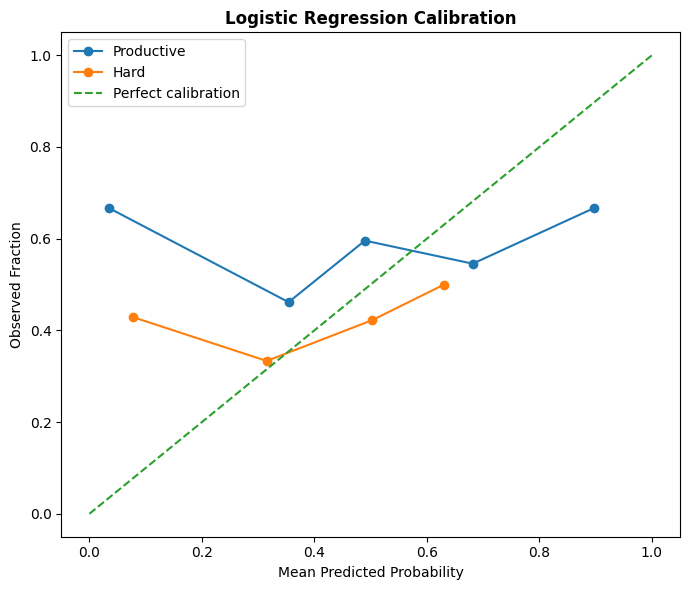

In [76]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

# Productive = class 1
true_productive = (y_cls_val == 1).astype(int)

frac_pos_prod, mean_pred_prod = calibration_curve(
    true_productive,
    logreg_prob[:, 1],
    n_bins=5,
    strategy="uniform"
)

ax.plot(
    mean_pred_prod,
    frac_pos_prod,
    marker="o",
    label="Productive"
)

# Hard = class 2
true_hard = (y_cls_val == 2).astype(int)

frac_pos_hard, mean_pred_hard = calibration_curve(
    true_hard,
    logreg_prob[:, 2],
    n_bins=5,
    strategy="uniform"
)

ax.plot(
    mean_pred_hard,
    frac_pos_hard,
    marker="o",
    label="Hard"
)

# Perfect calibration
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction")
ax.set_title(
    "Logistic Regression Calibration",
    fontweight="bold"
)

ax.legend()
plt.tight_layout()
plt.show()

In [77]:
import numpy as np

brier_productive = np.mean(
    ((y_cls_val == 1).astype(int) - logreg_prob[:, 1]) ** 2
)

brier_hard = np.mean(
    ((y_cls_val == 2).astype(int) - logreg_prob[:, 2]) ** 2
)

print(f"Productive Brier score: {brier_productive:.4f}")
print(f"Hard Brier score:       {brier_hard:.4f}")

Productive Brier score: 0.2847
Hard Brier score:       0.2684


# 29. Calibration

The calibration curves are far from the green \(y=x\) line, so the predicted probabilities are not reliable. For Productive, the model is badly underconfident in some low-probability bins and overconfident at higher probabilities; Hard shows similar deviations. The Brier scores are also weak: 0.2920 for Productive and 0.2679 for Hard. In fact, a dumb predictor that always outputs the test-set class prevalence would have Brier scores of roughly 0.245 for Productive and 0.243 for Hard, so Logistic Regression is not even improving probability quality over that trivial probability baseline.

So the full experimental conclusion is now very consistent:

	

# The current 10 handcrafted prompt features are the bottleneck.


In [82]:
import joblib
from pathlib import Path

STATIC_DIR = Path(
    r"C:\Users\waqar\OneDrive\Desktop\Fellowship\week4_static"
)

STATIC_DIR.mkdir(parents=True, exist_ok=True)

static_bundle = {
    "feature_cols": FEATURE_COLS,

    # Length head
    "length_scaler": scaler,
    "length_model": ridge,

    # Difficulty head
    "difficulty_scaler": scaler_cls,
    "difficulty_model": logreg,

    # Metadata
    "length_model_name": "Ridge",
    "difficulty_model_name": "LogisticRegression_balanced",
    "random_state": 42,
    "source": "Week 3 frozen static baseline",
}

save_path = STATIC_DIR / "week3_static_predictor.joblib"

joblib.dump(static_bundle, save_path)

print("Saved frozen Week 3 predictor to:")
print(save_path)

Saved frozen Week 3 predictor to:
C:\Users\waqar\OneDrive\Desktop\Fellowship\week4_static\week3_static_predictor.joblib


In [83]:
loaded = joblib.load(save_path)

print("Keys:")
print(loaded.keys())

print("\nLength model:")
print(type(loaded["length_model"]).__name__)

print("Length scaler:")
print(type(loaded["length_scaler"]).__name__)

print("\nDifficulty model:")
print(type(loaded["difficulty_model"]).__name__)

print("Difficulty scaler:")
print(type(loaded["difficulty_scaler"]).__name__)

print("\nFeatures:")
print(loaded["feature_cols"])

Keys:
dict_keys(['feature_cols', 'length_scaler', 'length_model', 'difficulty_scaler', 'difficulty_model', 'length_model_name', 'difficulty_model_name', 'random_state', 'source'])

Length model:
Ridge
Length scaler:
StandardScaler

Difficulty model:
LogisticRegression
Difficulty scaler:
StandardScaler

Features:
['n_chars', 'n_words', 'n_sentences', 'n_numbers', 'n_op_symbols', 'n_op_words', 'n_questions', 'n_commas', 'avg_word_len', 'n_hard_cues']
